#**Trabalho Final**

Desenvolver, em Python, uma aplicação utilizando regressão logística para lidar com o problema de classificação no dataset *Daphnet Freezing of Gait*.

## Importação de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Upload e extração automática do dataset em .zip

In [18]:
from google.colab import files
uploaded = files.upload()

import zipfile, os
import pandas as pd
import numpy as np

zip_name = list(uploaded.keys())[0]
extract_dir = 'daphnet_dataset'
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(extract_dir)
print('Arquivos extraídos em:', extract_dir)

Saving daphnet+freezing+of+gait.zip to daphnet+freezing+of+gait (1).zip
Arquivos extraídos em: daphnet_dataset


## Leitura e concatenação de todos os arquivos .txt dentro do zip

In [19]:
cols = ['time_ms','ankle_forward_mg','ankle_vertical_mg','ankle_lateral_mg',
        'thigh_forward_mg','thigh_vertical_mg','thigh_lateral_mg',
        'trunk_forward_mg','trunk_vertical_mg','trunk_lateral_mg','annotation']

data_files = []
for root, dirs, files in os.walk(extract_dir):
    for f in files:
        if f.lower().endswith(('.txt','.csv')):
            data_files.append(os.path.join(root, f))

dfs = []
for f in data_files:
    try:
        df = pd.read_csv(f, delim_whitespace=True, header=None, comment='#', engine='python')
        if df.shape[1] >= len(cols):
            df = df.iloc[:, :len(cols)]
            df.columns = cols
            df['source_file'] = os.path.basename(f)
            dfs.append(df)
    except Exception as e:
        print('Erro lendo', f, e)

data = pd.concat(dfs, ignore_index=True)
print('Linhas totais:', len(data))
print('Distribuição das anotações:\n', data['annotation'].value_counts())
data.head()

/tmp/ipython-input-616934589.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f, delim_whitespace=True, header=None, comment='#', engine='python')
/tmp/ipython-input-616934589.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f, delim_whitespace=True, header=None, comment='#', engine='python')
/tmp/ipython-input-616934589.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f, delim_whitespace=True, header=None, comment='#', engine='python')
/tmp/ipython-input-616934589.py:14: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(f, de

Linhas totais: 1917887
Distribuição das anotações:
 annotation
1    1030050
0     777052
2     110785
Name: count, dtype: int64


,time_ms,ankle_forward_mg,ankle_vertical_mg,ankle_lateral_mg,thigh_forward_mg,thigh_vertical_mg,thigh_lateral_mg,trunk_forward_mg,trunk_vertical_mg,trunk_lateral_mg,annotation,source_file
0,15,60,39,-970,0,0,0,0,0,0,0,S06R01.txt
1,31,60,39,-970,0,0,0,0,0,0,0,S06R01.txt
2,46,50,19,-960,0,0,0,0,0,0,0,S06R01.txt
3,62,50,19,-960,0,0,0,0,0,0,0,S06R01.txt
4,78,40,49,-950,0,0,0,0,0,0,0,S06R01.txt


## Pré-processamento e separação de treino/teste

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Filtrar apenas experimentos válidos (1 e 2)
data_exp = data[data['annotation'].isin([1,2])].copy()
data_exp['label'] = (data_exp['annotation'] == 2).astype(int)

feature_cols = cols[1:10]
X = data_exp[feature_cols].astype(float).fillna(method='ffill').fillna(method='bfill')
y = data_exp['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]

print('Acurácia:', (y_pred == y_test).mean())
print('\nRelatório de Classificação:\n', classification_report(y_test, y_pred, digits=4))
print('\nMatriz de Confusão:\n', confusion_matrix(y_test, y_pred))
print('\nROC AUC:', roc_auc_score(y_test, y_proba))

/tmp/ipython-input-4000323087.py:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = data_exp[feature_cols].astype(float).fillna(method='ffill').fillna(method='bfill')


Acurácia: 0.5403931853482884

Relatório de Classificação:
               precision    recall  f1-score   support

           0     0.9657    0.5091    0.6667    257513
           1     0.1541    0.8318    0.2601     27696

    accuracy                         0.5404    285209
   macro avg     0.5599    0.6704    0.4634    285209
weighted avg     0.8869    0.5404    0.6272    285209


Matriz de Confusão:
 [[131088 126425]
 [  4659  23037]]

ROC AUC: 0.7229129603566109


## Matriz de Confusão

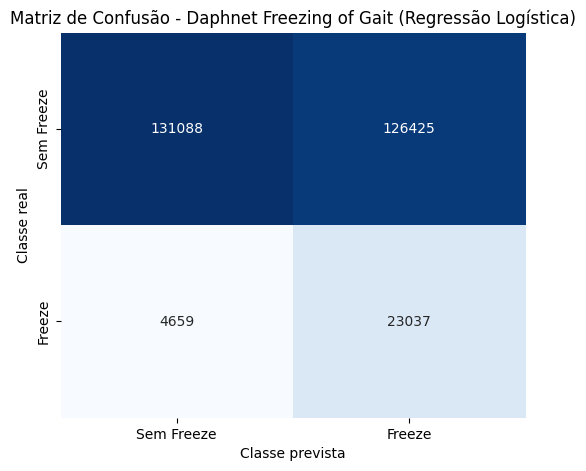

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gera a matriz
cm = confusion_matrix(y_test, y_pred)

# Cria o gráfico
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Sem Freeze", "Freeze"],
            yticklabels=["Sem Freeze", "Freeze"])
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão - Daphnet Freezing of Gait (Regressão Logística)")
plt.show()

## Curva ROC

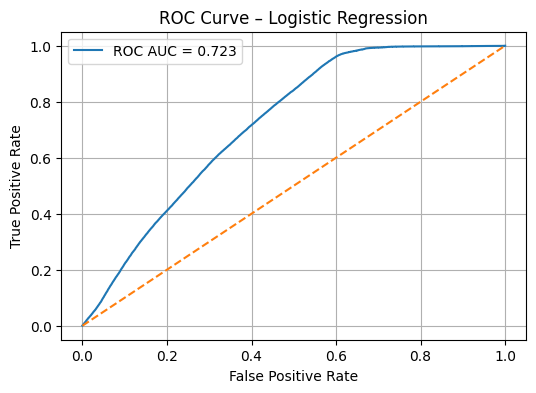

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc_score(y_test, y_proba):.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

## Exemplo de aceleração de Sinal

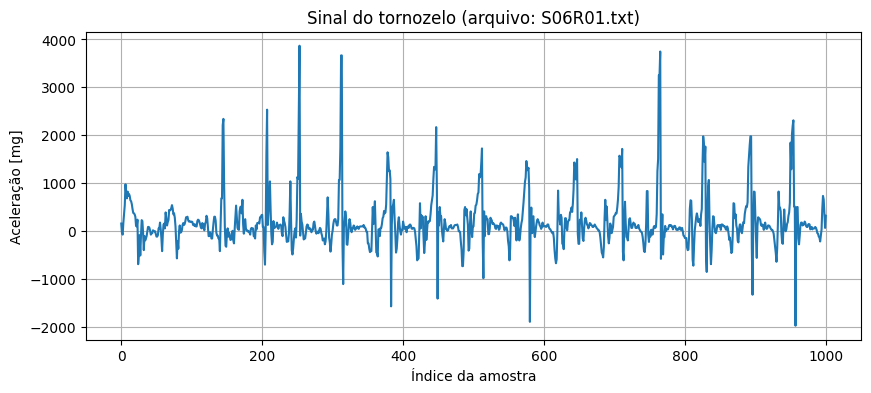

In [26]:
files_with_freeze = data_exp[data_exp['label']==1]['source_file'].unique()
if len(files_with_freeze) > 0:
    sample_file = files_with_freeze[0]
    df_sample = data_exp[data_exp['source_file']==sample_file].reset_index(drop=True)
    idx_freeze = df_sample[df_sample['label']==1].index
    if len(idx_freeze)>0:
        start = max(0, idx_freeze[0]-200)
        end = min(len(df_sample), idx_freeze[0]+800)
    else:
        start,end = 0, min(len(df_sample),2000)
    window = df_sample.loc[start:end,:].reset_index(drop=True)
    plt.figure(figsize=(10,4))
    plt.plot(window.index, window['ankle_forward_mg'])
    plt.xlabel('Índice da amostra')
    plt.ylabel('Aceleração [mg]')
    plt.title(f'Sinal do tornozelo (arquivo: {sample_file})')
    plt.grid(True)
    plt.show()
else:
    print('Nenhum arquivo com freeze encontrado para plotar.')

## Visão geral e distribuição de classes

Dimensões do dataset: (90882, 12)

Valores únicos em 'annotation': [1 2]

Distribuição das classes (rótulos):
annotation
1    74848
2    16034
Name: count, dtype: int64


/tmp/ipython-input-2799560852.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='annotation', data=df, palette='Set2')


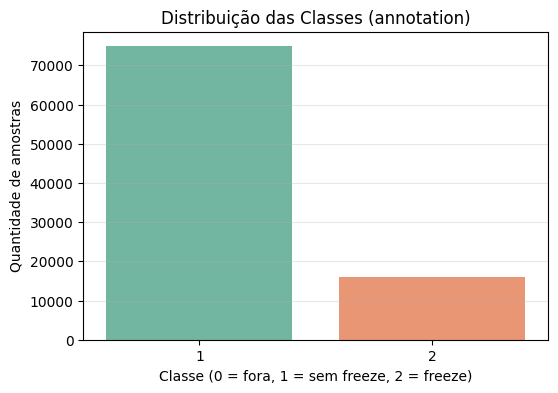

In [27]:
# Informações gerais
print("Dimensões do dataset:", df.shape)
print("\nValores únicos em 'annotation':", df['annotation'].unique())
print("\nDistribuição das classes (rótulos):")
print(df['annotation'].value_counts())

# Gráfico da distribuição das classes
plt.figure(figsize=(6,4))
sns.countplot(x='annotation', data=df, palette='Set2')
plt.title("Distribuição das Classes (annotation)")
plt.xlabel("Classe (0 = fora, 1 = sem freeze, 2 = freeze)")
plt.ylabel("Quantidade de amostras")
plt.grid(axis='y', alpha=0.3)
plt.show()

## Correlação entre sensores (sem freeze x freeze)

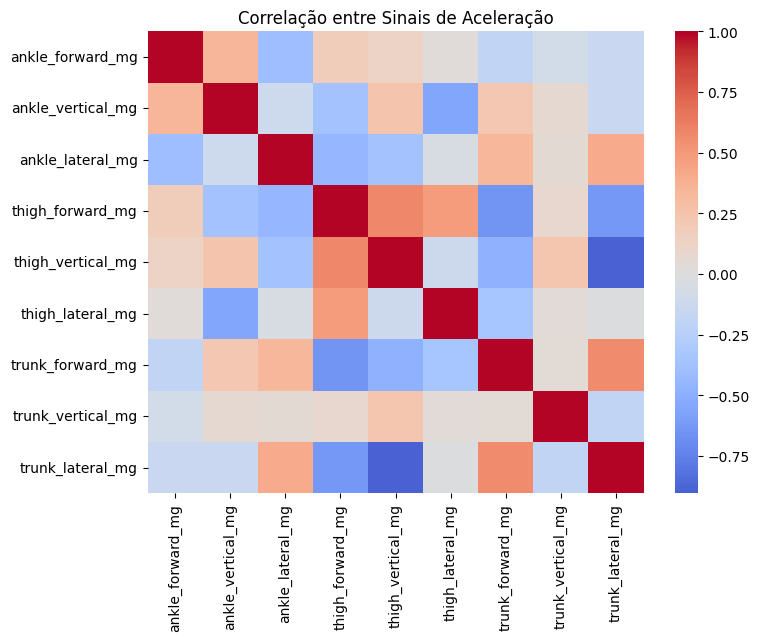

In [29]:
# Mantém apenas as amostras dentro do experimento
df_exp = df[df["annotation"] != 0]

# Correlação entre sensores
corr = df_exp.drop(columns=["annotation", "time_ms", "source_file"]).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title("Correlação entre Sinais de Aceleração")
plt.show()